# 读取图像，转成tensor

In [ ]:
import torch
import torch.nn as nn
import numpy as np
from PIL import Image#################如果要在python中读取图片，需要把PIL的这个包
from torchvision import transforms#变换的
import torch.nn.functional as F
import matplotlib.pyplot as plt

image_name = 'lenaOriginal.png'
img = Image.open(image_name)
print(type(img))

img = np.array(img)
print(img.shape) #转numpy
print("-------------------")

print(img)
print(img.transpose((2, 0, 1)).shape)

print("-------------------")
img = torch.from_numpy(img.transpose((2, 0, 1)))#转变为（3，512，512）的torch矩阵
print(img.shape)



img = img.numpy().transpose((1, 2, 0))
print(img.shape)



<class 'PIL.PngImagePlugin.PngImageFile'>
(512, 512, 3)
-------------------
[[[191 134  82]
  [191 134  82]
  [189 133  81]
  ...
  [133  83  52]
  [133  83  52]
  [133  83  52]]

 [[191 134  82]
  [191 134  82]
  [189 133  81]
  ...
  [133  83  52]
  [133  83  52]
  [133  83  52]]

 [[188 128  81]
  [188 128  81]
  [193 136  82]
  ...
  [136  83  49]
  [133  83  49]
  [133  83  49]]

 ...

 [[161 100  61]
  [161 100  61]
  [164 106  66]
  ...
  [ 39  21  21]
  [ 39  21  21]
  [ 39  21  21]]

 [[158  97  60]
  [158  97  60]
  [162 101  64]
  ...
  [ 38  20  21]
  [ 38  20  20]
  [ 38  20  20]]

 [[158  97  60]
  [158  97  60]
  [162 101  64]
  ...
  [ 38  20  21]
  [ 38  20  20]
  [ 38  20  20]]]
(3, 512, 512)
-------------------
torch.Size([3, 512, 512])
(512, 512, 3)


In [28]:
#!conda install torchvision -y
#!conda install -c conda-forge onnx onnxruntime -y

<class 'PIL.Image.Image'>
<PIL.Image.Image image mode=RGB size=512x512 at 0x1E3D0F1F610>
<class 'torch.Tensor'>
torch.Size([3, 512, 512])
tensor([[[0.7490, 0.7490, 0.7412,  ..., 0.5216, 0.5216, 0.5216],
         [0.7490, 0.7490, 0.7412,  ..., 0.5216, 0.5216, 0.5216],
         [0.7373, 0.7373, 0.7569,  ..., 0.5333, 0.5216, 0.5216],
         ...,
         [0.6314, 0.6314, 0.6431,  ..., 0.1529, 0.1529, 0.1529],
         [0.6196, 0.6196, 0.6353,  ..., 0.1490, 0.1490, 0.1490],
         [0.6196, 0.6196, 0.6353,  ..., 0.1490, 0.1490, 0.1490]],

        [[0.5255, 0.5255, 0.5216,  ..., 0.3255, 0.3255, 0.3255],
         [0.5255, 0.5255, 0.5216,  ..., 0.3255, 0.3255, 0.3255],
         [0.5020, 0.5020, 0.5333,  ..., 0.3255, 0.3255, 0.3255],
         ...,
         [0.3922, 0.3922, 0.4157,  ..., 0.0824, 0.0824, 0.0824],
         [0.3804, 0.3804, 0.3961,  ..., 0.0784, 0.0784, 0.0784],
         [0.3804, 0.3804, 0.3961,  ..., 0.0784, 0.0784, 0.0784]],

        [[0.3216, 0.3216, 0.3176,  ..., 0.2039, 0.

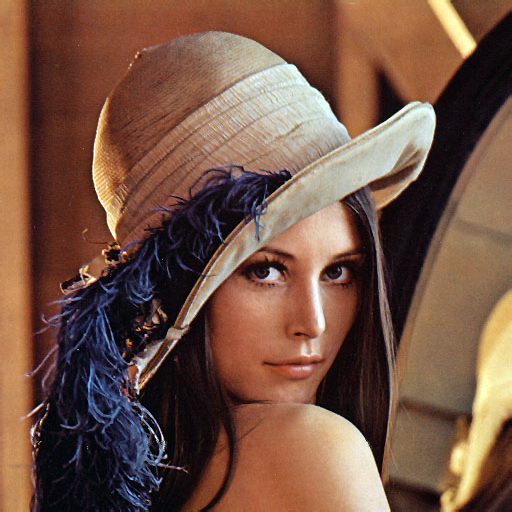

In [29]:
pil_image = Image.open(image_name).convert('RGB')

print(type(pil_image))
print(pil_image)

tensor_image = transforms.ToTensor()(pil_image)

print(type(tensor_image))
print(tensor_image.shape)
print(tensor_image)

batch_image = tensor_image.unsqueeze(0)

print(batch_image.shape)

restored_tensor = batch_image.squeeze(0)

print(restored_tensor.shape)

restored_pil_image = transforms.ToPILImage()(restored_tensor)

print(type(restored_pil_image))
display(restored_pil_image)

In [30]:
# 图像预处理 normalization
norm_mean = [0.485, 0.456, 0.406]
norm_std = [0.229, 0.224, 0.225]

normalize = transforms.Normalize(
    mean=norm_mean,
    std=norm_std,
    inplace=False
)

#print(totensor(image))

image_nor = normalize(totensor(image))#...........................................
print(image_nor.mean(), image_nor.std())
print(image_nor.shape)

image_nor = toPIL(image_nor)
print(type(image_nor), image_nor)
image_nor.save("lena_normalized.jpg")
#image_nor.show()

tensor(-0.4199) tensor(1.0752)
torch.Size([3, 512, 512])
<class 'PIL.Image.Image'> <PIL.Image.Image image mode=RGB size=512x512 at 0x1E3D24F9950>


# 图像卷积

In [31]:
# 卷积
x = torch.tensor([[[[3., 0., 1., 2., 7., 4.], 
	              [1., 5., 8., 9., 3., 1.], 
	              [2., 7., 2., 5., 1., 3.], 
	              [0., 1., 3., 1., 7., 8.], 
	              [4., 2., 1., 6., 2., 8.],
	              [2., 4., 5., 2., 3., 9.]]]], requires_grad=False)


w = torch.tensor([[[[1., 0., -1.], 
				  [1., 0., -1.],
				  [1., 0., -1.]]]], requires_grad=True)


print(x.shape, w.shape)

out = F.conv2d(x, w, stride=1, padding=0) #n=6, f=3, o=4
print(out.shape)

out1 = F.conv2d(x, w, stride=1, padding=1) #n+2p-f+1=6
print(out1.shape)

out2 = F.conv2d(x, w, stride=2, padding=0) #(n-f)/s+1=2
print(out2.shape)

torch.Size([1, 1, 6, 6]) torch.Size([1, 1, 3, 3])
torch.Size([1, 1, 4, 4])
torch.Size([1, 1, 6, 6])
torch.Size([1, 1, 2, 2])


In [32]:
# 灰度图卷积：边缘检测
grayimage = image.convert('L') #
grayimage = totensor(grayimage).unsqueeze(0)
print(grayimage.shape)

w = torch.tensor([[[[1., 0., -1.], 
				  [2., 0., -2.],
				  [1., 0., -1.]]]])

convv = F.conv2d(grayimage, w, stride=1, padding=0)#

print("after conv2d ", convv.shape)

convv = convv.squeeze(0)#4d->3d

print(convv.shape)

convv = toPIL(convv)
convv.show()

torch.Size([1, 1, 512, 512])
after conv2d  torch.Size([1, 1, 510, 510])
torch.Size([1, 510, 510])


In [33]:
# padding
print(grayimage.shape)
convpad = F.conv2d(grayimage, w, stride=1, padding=10)
convpad = convpad.squeeze(0)
print(convpad.shape)
convpad = toPIL(convpad)
convpad.show()

torch.Size([1, 1, 512, 512])
torch.Size([1, 530, 530])


In [34]:
# 步长
convstride = F.conv2d(grayimage, w, stride=2, padding=0)
convstride = convstride.squeeze(0)
#print(convpad.shape)
convstride = toPIL(convstride)
convstride.show()

In [35]:
# 水平线检测
w2 = torch.tensor([[[[1., 2., 1.], 
				  [0., 0., 0.],
				  [-1., -2., -1.]]]])
convh = F.conv2d(grayimage, w2, stride=1, padding=0)
convh = convh.squeeze(0)
convh = toPIL(convh)
convh.show()

In [36]:
# 多通道卷积（RGB）
image = Image.open(image_name).convert('RGB')##############Image

image = totensor(image).unsqueeze(0)# 3d --> 4d

print(image.shape)

#yellow kernel
w = torch.tensor([[[[1., 0., -1.], 
				  [2., 0., -2.],
				  [1., 0., -1.]]]])

print("before, w.shape= ", w.shape)

w = w.repeat(1,3,1,1)

print("after, w.shape= ", w.shape)

convv = F.conv2d(image, w, stride=1, padding=0)
convv = convv.squeeze(0)
convv = toPIL(convv)
convv.show()

print(w)

torch.Size([1, 3, 512, 512])
before, w.shape=  torch.Size([1, 1, 3, 3])
after, w.shape=  torch.Size([1, 3, 3, 3])
tensor([[[[ 1.,  0., -1.],
          [ 2.,  0., -2.],
          [ 1.,  0., -1.]],

         [[ 1.,  0., -1.],
          [ 2.,  0., -2.],
          [ 1.,  0., -1.]],

         [[ 1.,  0., -1.],
          [ 2.,  0., -2.],
          [ 1.,  0., -1.]]]])


In [37]:
convpad = F.conv2d(image, w, stride=1, padding=10)
convpad = convpad.squeeze(0)
convpad = toPIL(convpad)
convpad.show()

In [38]:
convstride = F.conv2d(image, w, stride=2, padding=0)
convstride = convstride.squeeze(0)
convstride = toPIL(convstride)
convstride.show()

In [40]:
# 多卷积核
w2 = torch.tensor([[[[1., 2., 1.], 
				  [0., 0., 0.],
				  [-1., -2., -1.]]]])#进行水平检测的

print(w.shape)
w2 = w2.repeat(1,3,1,1)#建立成匹配RGB样式的卷积核
print("w2.shape=", w2.shape)

print("----------------------------------")
w3 = torch.cat((w,w2),0)#把两个重合一下得到（2，3，3，3）
print("first cat, w3.shape=", w3.shape)
w3 = torch.cat((w3,w2),0)#把重合过的w3与w2重合之后得到（3，3，3，3）
print("secode cat, w3.shape=", w3.shape)

convh = F.conv2d(image, w3, stride=1, padding=0)

print("convh.shape = ", convh.shape)
convh = convh.squeeze(0)
convh = toPIL(convh)
convh.show()

torch.Size([1, 3, 3, 3])
w2.shape= torch.Size([1, 3, 3, 3])
----------------------------------
first cat, w3.shape= torch.Size([2, 3, 3, 3])
secode cat, w3.shape= torch.Size([3, 3, 3, 3])
convh.shape =  torch.Size([1, 3, 510, 510])
